In [4]:
!pip install --user kaggle

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [kaggle]  WARNING: The script kaggle is installed in '/home/jovyan/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kaggle]


In [9]:
!/home/jovyan/.local/bin/kaggle --version

Kaggle CLI 2.0.1


In [13]:
import os
os.environ['PATH'] += ':/home/jovyan/.local/bin'

In [14]:
import os

os.environ['KAGGLE_USERNAME'] = 
os.environ['KAGGLE_KEY'] = 

# 인증 확인
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [15]:
!kaggle competitions download -c aiffel-d-lthon-dktc-online-17

100%|████████████████████████████████████████| 906k/906k [00:00<00:00, 1.06MB/s]



In [16]:
!unzip -q aiffel-d-lthon-dktc-online-17.zip -d ./data

In [5]:
import pandas as pd

train_data = pd.read_csv('./data/train.csv')
test_data = pd.read_csv('./data/test.csv')

In [21]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idx           3950 non-null   int64 
 1   class         3950 non-null   object
 2   conversation  3950 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.7+ KB


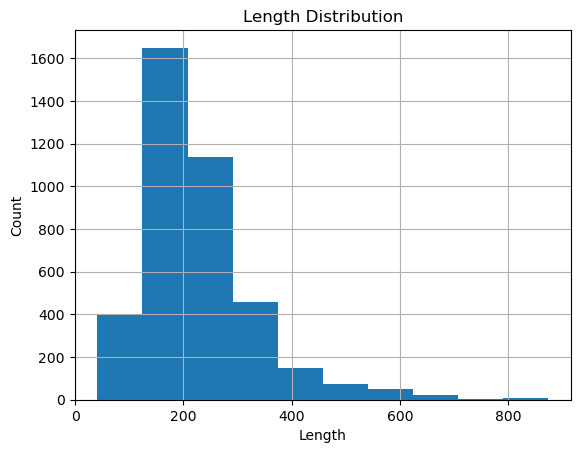

In [22]:
import matplotlib.pyplot as plt

# 길이 분포 히스토그램 시각화
train_data['conversation'].str.len().hist()
plt.title('Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()


In [23]:
import pandas as pd
import re

# 대표적인 비속어/거친 표현 키워드 리스트 (필요시 추가)
slang_keywords = ['새끼', '미친', '존나', '씨발', '죽여', '병신', '지랄', '꺼져']

# 비속어가 포함된 데이터 개수 카운트
def count_slang(text):
    for word in slang_keywords:
        if word in str(text):
            return True
    return False

# 원본 훈련 데이터(train_df) 기준
train_data['has_slang'] = train_data['conversation'].apply(count_slang)
slang_ratio = train_data['has_slang'].mean() * 100

print(f"전체 데이터 중 비속어 포함 비율: {slang_ratio:.2f}%")

전체 데이터 중 비속어 포함 비율: 21.72%


In [6]:
import pandas as pd

normal_df = pd.read_csv("final_normal_conversations_1000.csv")

#  데이터 합치기
# 기존 train 데이터와 새로 만든 데이터의 컬럼 구성이 [idx, class, conversation]으로 동일하므로 바로 합칩니다.
final_train_df = pd.concat([train_data, normal_df], axis=0).reset_index(drop=True)

# 결과 확인
print(f"기존 데이터 개수: {len(train_data)}")
print(f"추가된 일반 대화 개수: {len(normal_df)}")
print(f"최종 합계 데이터 개수: {len(final_train_df)}")

# 클래스별 분포 확인 (잘 들어갔는지 체크)
print(final_train_df['class'].value_counts())

기존 데이터 개수: 3950
추가된 일반 대화 개수: 895
최종 합계 데이터 개수: 4845
class
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
일반 대화           895
Name: count, dtype: int64


In [7]:
import pandas as pd
import re

# 1. 데이터 로드 (파일명을 본인의 것으로 수정하세요)
file_name = 'final_normal_conversations_1000.csv' 
train_data = pd.read_csv(file_name) 

print(f"초기 로드 데이터 개수: {len(train_data)}")

# 2. 표준 전처리 함수 정의
def standard_preprocess(text):
    if not isinstance(text, str):
        return ""
    # 공백 정규화
    text = re.sub(r'\s+', ' ', text)
    # URL 및 이메일 제거
    text = re.sub(r'http\S+|www\S+|mailto:\S+', '', text)
    # 한글, 숫자, 영문, 자음/모음, 기본 문장부호만 남기기
    text = re.sub(r'[^가-힣0-9a-zA-Zㄱ-ㅎㅏ-ㅣ\s.?!,]', '', text)
    return text.strip()

# 3. 전처리 적용 (변수명 train_data가 정확히 포함되어야 합니다)
train_data['conversation'] = train_data['conversation'].apply(standard_preprocess)

# 4. 클래스 라벨 맵핑 (모든 케이스 대응)
label_dict = {
    '협박 대화': 0, '협박': 0, '협박대화': 0,
    '갈취 대화': 1, '갈취': 1, '갈취대화': 1,
    '직장 내 괴롭힘 대화': 2, '직장내괴롭힘': 2, '직장내괴롭힘대화': 2,
    '기타 괴롭힘 대화': 3, '기타괴롭힘': 3, '기타괴롭힘대화': 3,
    '일반 대화': 4, '일반': 4, '일반대화': 4
}

# label 컬럼 생성
if 'class' in train_data.columns:
    train_data['label'] = train_data['class'].map(label_dict)
else:
    print("'class' 컬럼을 찾을 수 없습니다!")

# 5. 중복 및 결측치 제거
# 정제된 텍스트('conversation')를 기준으로 중복 제거
train_data = train_data.drop_duplicates(subset=['conversation']).dropna(subset=['label'])

# 6. 불필요한 컬럼 삭제 및 정리
if 'idx' in train_data.columns:
    train_data.drop(['idx'], axis=1, inplace=True)

final_df = train_data[['conversation', 'label']].copy()

print("-" * 30)
print(f"최종 정제 후 데이터 개수: {len(final_df)}")
print("\n[최종 라벨 분포]")
print(final_df['label'].value_counts().sort_index())
print("-" * 30)
print(final_df.head())

초기 로드 데이터 개수: 895
------------------------------
최종 정제 후 데이터 개수: 895

[최종 라벨 분포]
label
4    895
Name: count, dtype: int64
------------------------------
                                        conversation  label
0  어제 마트 갔다 왔는데 진짜 사람이 너무 많더라고. 그치, 주말이잖아. 나도 오전에...      4
1  이거 어떻게 하는 거야 진짜 모르겠어. 어디 부분? 설정 들어가서 위에 보면 있잖아...      4
2  오늘 점심 뭐 먹었어? 회사 근처 새로 생긴 데 갔는데 별로였어. 돈까스였는데 튀김...      4
3  야 나 오늘 지각할 뻔 했잖아. 또? 왜 이번엔. 버스를 잘못 탔어. 반대 방향으로...      4
4  이 영화 봤어? 요즘 되게 핫하던데. 아직. 보려고 했는데 시간이 없어서. 나 어제...      4


In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 20.0.0
    Uninstalling pyarrow-20.0.0:
      Successfully uninstalled pyarrow-20.0.0━━━━━━━━━━━━━━━━━━━━━  2/20 [pyarrow]
  Attempting uninstall: dill90m╺━━━━━━━━━━━━━━━━━━━━━━━━━  7/20 [frozenlist]
    Found existing installation: dill 0.4.0━━━━━━━━━━━━━━━━━━━  7/20 [frozenlist]
    Uninstalling dill-0.4.0:━━━━━━━━━━━━━━━━━━━━━━━━━  7/20 [frozenlist]
      Successfully uninstalled dill-0.4.0━━━━━━━━━━━━━━━━━━━━━  7/20 [frozenlist]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [datasets]/20 [datasets]ce-hub]


In [5]:
!pip uninstall -y pyarrow
!pip install --no-cache-dir pyarrow datasets --upgrade

Found existing installation: pyarrow 24.0.0
Uninstalling pyarrow-24.0.0:
  Successfully uninstalled pyarrow-24.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.9 MB/s eta 0:00:00a 0:00:01


In [2]:
!pip install transformers accelerate scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 2.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 3.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [transformers] [transformers]


In [9]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    set_seed
)

# ==========================================
# 1. 공통 학습 세팅 (요청하신 하이퍼파라미터)
# ==========================================
MODEL_NAME = "klue/roberta-large"
MAX_LENGTH = 256
EPOCHS = 3
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
SEED = 42

# 시드 고정 (재현성 확보)
set_seed(SEED)

# ==========================================
# 2. 데이터셋 분리 및 Hugging Face Dataset 변환
# ==========================================
# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(final_df, test_size=0.2, random_state=SEED, stratify=final_df['label'])

# Pandas DataFrame을 Hugging Face Dataset 객체로 변환
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# ==========================================
# 3. 토크나이저 로드 및 토큰화
# ==========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["conversation"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

# map 함수를 사용하여 토큰화 적용 (빠른 처리)
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# 불필요한 컬럼(원본 텍스트 등) 제거 및 모델 입력 포맷으로 변환
tokenized_train = tokenized_train.remove_columns(["conversation", "__index_level_0__"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_train.set_format("torch")

tokenized_val = tokenized_val.remove_columns(["conversation", "__index_level_0__"])
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_val.set_format("torch")

# ==========================================
# 4. 모델 로드 및 Trainer 설정
# ==========================================
# 5개의 클래스를 분류하는 모델 로드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",  # 매 에포크마다 검증
    save_strategy="epoch",
    logging_dir="./logs",
    seed=SEED,
    load_best_model_at_end=True,  # 가장 성능이 좋았던 모델 저장
)

# 정확도 계산 함수
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    accuracy = (preds == labels).mean()
    return {"accuracy": accuracy}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# ==========================================
# 5. 모델 학습 시작
# ==========================================
print("학습을 시작합니다...")
trainer.train()
print("학습 완료!")

# ==========================================
# 6. 테스트 문장으로 예측해보기 (Inference)
# ==========================================
# 라벨 디코딩을 위한 딕셔너리 (전처리 코드의 반대)
id2label = {
    0: '협박 대화', 
    1: '갈취 대화', 
    2: '직장 내 괴롭힘 대화', 
    3: '기타 괴롭힘 대화', 
    4: '일반 대화'
}

model.eval() # 평가 모드로 전환

def predict_sentence(sentence):
    # 전처리 함수(standard_preprocess)를 동일하게 적용
    clean_sentence = standard_preprocess(sentence)
    
    # 토큰화
    inputs = tokenizer(
        clean_sentence, 
        return_tensors="pt", 
        max_length=MAX_LENGTH, 
        padding="max_length", 
        truncation=True
    ).to(device)
    
    # 예측
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=-1).item()
        
    return id2label[predicted_class_id]

# 테스트 해볼 문장 리스트
test_sentences = [
    "오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.", # 예상: 일반 대화
    "너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?", # 예상: 협박 대화 또는 직장내 괴롭힘
    "야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.", # 예상: 갈취 대화
    "김대리, 일 처리 이따위로 할거야? 머리가 장식이야?", # 예상: 직장 내 괴롭힘 대화
    "어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네." # 예상: 기타 괴롭힘 대화
]

print("\n" + "="*40)
print("📝 테스트 문장 예측 결과")
print("="*40)

for text in test_sentences:
    pred_label = predict_sentence(text)
    print(f"입력 문장: {text}")
    print(f"예측 결과: [{pred_label}]\n")

Map:   0%|          | 0/716 [00:00<?, ? examples/s]

Map:   0%|          | 0/179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


학습을 시작합니다...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.000335,1.000000
2,No log,0.000227,1.000000
3,No log,0.000205,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

학습 완료!

📝 테스트 문장 예측 결과
입력 문장: 오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.
예측 결과: [일반 대화]

입력 문장: 너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?
예측 결과: [일반 대화]

입력 문장: 야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.
예측 결과: [일반 대화]

입력 문장: 김대리, 일 처리 이따위로 할거야? 머리가 장식이야?
예측 결과: [일반 대화]

입력 문장: 어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네.
예측 결과: [일반 대화]



In [10]:
additional_test_sentences = [
    "오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.", # 예상: 일반 대화
    "너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?", # 예상: 협박 대화 또는 직장내 괴롭힘
    "야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.", # 예상: 갈취 대화
    "김대리, 일 처리 이따위로 할거야? 머리가 장식이야?", # 예상: 직장 내 괴롭힘 대화
    "어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네.", # 예상: 기타 괴롭힘 대화
    # 첫 번째 리스트
    "저번에 빌려간 5만원 말이야, 내가 지금 사정이 너무 급해서 그러는데 내일까지만 꼭 좀 돌려줄 수 있을까? 부탁해!",
    "야, 너 요즘 회사 게시판에 이상한 글 쓰고 다닌다며? 입조심 안 하면 진짜 가만 안 둔다. 니네 집 주소 아는 거 어렵지 않아.",
    "아니, 내가 언제 그랬어? 자꾸 사람 이상하게 몰아가지 마세요. 진짜 짜증 나니까 그만 좀 하시라고요!",
    "아니 진짜 미친 거 아냐? 일을 이따위로 해놓고 퇴근을 한다고? 야, 너 진짜 제정신이면 다시 앉아서 이거 다 고쳐놔. 당장!",
    "우리 OO씨, 요즘 많이 힘들죠? 제가 다 이해해요. 근데 저번에 말한 그 비밀 말이에요... 제가 입만 벙긋 안 하면 아무도 모를 텐데, 그쵸? 내일 점심 같이 하면서 얘기 좀 할까요?",
    "야! 너 진짜 죽고 싶어 환장했냐? ㅋㅋㅋㅋ 어떻게 게임을 이렇게 못하냐? 아 진짜 웃겨서 배 아파 죽겠네.",
    
    # 두 번째 리스트
    "대리님, 혹시 내일 오전 회의 자료 프린트 다 해두셨을까요? 제가 지금 외부 미팅 중이라서요!",
    "이번 주말에 날씨 엄청 좋다는데 한강 가서 치맥 어때? 내가 돗자리 챙겨갈게.",
    "고객님, 주문하신 상품은 내일 오후 쯤에 배송 완료될 예정입니다. 이용해 주셔서 감사합니다.",
    "아까 보내준 유튜브 링크 들어가봤는데 진짜 웃기더라 ㅋㅋㅋ 나중에 다른 애들한테도 보여줘야지.",
    "프로젝트 마감일이 다음 주 금요일로 연기되었으니, 다들 일정 참고하셔서 여유 있게 진행해 주시기 바랍니다.",
    "너 자꾸 내 말 무시하고 맘대로 행동하면, 진짜 동네에 얼굴 못 들고 다니게 만들어버린다.",
    "야, 좋은 말 할 때 지갑 열어. 오늘 피시방 갈 돈이 좀 부족하네? 빨리 안 내놔?",
    "어휴, 넌 진짜 머리가 있는 거냐 없는 거냐? 그딴 식으로 일할 거면 그냥 회사 때려쳐.",
    "너 진짜 왜 그렇게 생겼냐? 냄새나니까 내 옆에 오지 마. 아, 진짜 짜증나게 하네.",
    "저기요, 혹시 이 근처에 지하철역 가려면 어느 방향으로 가야 하는지 아시나요?"
]

import torch.nn.functional as F

# 예측 함수 업데이트 (확신도 반환)
def predict_sentence_with_confidence(sentence):
    # 전처리 동일 적용
    clean_sentence = standard_preprocess(sentence)
    
    # 토큰화
    inputs = tokenizer(
        clean_sentence, 
        return_tensors="pt", 
        max_length=MAX_LENGTH, 
        padding="max_length", 
        truncation=True
    ).to(device)
    
    # 예측
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
        # 🌟 소프트맥스(Softmax)를 거쳐 0~1 사이의 확률값으로 변환
        probs = F.softmax(logits, dim=-1)
        
        # 가장 높은 확률값과 그 클래스 인덱스 추출
        max_prob, predicted_class_id = torch.max(probs, dim=-1)
        
        predicted_class_id = predicted_class_id.item()
        confidence = max_prob.item() * 100 # %로 변환
        
    return id2label[predicted_class_id], confidence


# 테스트 진행
print("\n" + "="*50)
print("📝 확신도가 포함된 테스트 문장 예측 결과")
print("="*50)

for text in additional_test_sentences: # (앞서 정의한 16개 문장 리스트)
    # 라벨과 확신도를 동시에 받아옵니다
    pred_label, confidence = predict_sentence_with_confidence(text)
    
    # 요청하신 포맷으로 출력
    print(f"문장: {text}")
    print(f"결과: {pred_label} (확신도: {confidence:.2f}%)\n")


📝 확신도가 포함된 테스트 문장 예측 결과
문장: 오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.
결과: 일반 대화 (확신도: 99.98%)

문장: 너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?
결과: 일반 대화 (확신도: 99.98%)

문장: 야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.
결과: 일반 대화 (확신도: 99.98%)

문장: 김대리, 일 처리 이따위로 할거야? 머리가 장식이야?
결과: 일반 대화 (확신도: 99.98%)

문장: 어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네.
결과: 일반 대화 (확신도: 99.98%)

문장: 저번에 빌려간 5만원 말이야, 내가 지금 사정이 너무 급해서 그러는데 내일까지만 꼭 좀 돌려줄 수 있을까? 부탁해!
결과: 일반 대화 (확신도: 99.98%)

문장: 야, 너 요즘 회사 게시판에 이상한 글 쓰고 다닌다며? 입조심 안 하면 진짜 가만 안 둔다. 니네 집 주소 아는 거 어렵지 않아.
결과: 일반 대화 (확신도: 99.98%)

문장: 아니, 내가 언제 그랬어? 자꾸 사람 이상하게 몰아가지 마세요. 진짜 짜증 나니까 그만 좀 하시라고요!
결과: 일반 대화 (확신도: 99.98%)

문장: 아니 진짜 미친 거 아냐? 일을 이따위로 해놓고 퇴근을 한다고? 야, 너 진짜 제정신이면 다시 앉아서 이거 다 고쳐놔. 당장!
결과: 일반 대화 (확신도: 99.98%)

문장: 우리 OO씨, 요즘 많이 힘들죠? 제가 다 이해해요. 근데 저번에 말한 그 비밀 말이에요... 제가 입만 벙긋 안 하면 아무도 모를 텐데, 그쵸? 내일 점심 같이 하면서 얘기 좀 할까요?
결과: 일반 대화 (확신도: 99.98%)

문장: 야! 너 진짜 죽고 싶어 환장했냐? ㅋㅋㅋㅋ 어떻게 게임을 이렇게 못하냐? 아 진짜 웃겨서 배 아파 죽겠네.
결과: 일반 대화 (확신도: 99.98%)

문장: 대리님, 혹시 내일 오전 회의 자료 프린트 다 해두셨을까요? 제가 지금 외부 미

In [24]:
import torch
import gc

# 1. 모든 객체 참조 해제 및 가비지 컬렉션
gc.collect()

# 2. GPU 캐시 강제 비우기
torch.cuda.empty_cache()

# 3. (선택) 현재 GPU 메모리 상태 확인
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.1f}MB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**2:.1f}MB")

Allocated: 1944.2MB
Reserved: 2084.0MB


In [15]:
# 데이터의 실제 토큰 길이 분포 확인하기
token_lengths = []
for text in final_df['conversation']:
    # 토큰화 후 길이만 측정
    length = len(tokenizer.encode(text, add_special_tokens=True))
    token_lengths.append(length)

import numpy as np
print(f"최대 길이: {np.max(token_lengths)}")
print(f"평균 길이: {np.mean(token_lengths):.1f}")
print(f"95% 커버 길이: {np.percentile(token_lengths, 95):.0f}")
print(f"99% 커버 길이: {np.percentile(token_lengths, 99):.0f}")

최대 길이: 491
평균 길이: 100.6
95% 커버 길이: 220
99% 커버 길이: 340


In [26]:
def debug_predict(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=256).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=-1).item()
        print(f"문장: {sentence[:20]}... -> 예측 라벨 숫자: {predicted_class_id}")

# 샘플 테스트
debug_predict("너 죽고 싶어? 돈 내놔")
debug_predict("오늘 날씨가 참 좋네요")

문장: 너 죽고 싶어? 돈 내놔... -> 예측 라벨 숫자: 4
문장: 오늘 날씨가 참 좋네요... -> 예측 라벨 숫자: 4


In [1]:
import pandas as pd

# 1. 기존 괴롭힘 데이터 로드 (파일 경로를 확인하세요)
# 만약 기존 데이터가 다른 파일에 있다면 그 파일을 로드해야 합니다.
origin_file = './data/train.csv' 
df_origin = pd.read_csv(origin_file)

# 2. 합성 데이터(일반 대화) 로드
normal_file = 'final_normal_conversations_1000.csv'
df_normal = pd.read_csv(normal_file)

# 3. 데이터 합치기 (두 데이터를 위아래로 붙임)
train_data = pd.concat([df_origin, df_normal], axis=0).reset_index(drop=True)

print(f"합친 후 전체 데이터 개수: {len(train_data)}")
print("포함된 클래스 종류:", train_data['class'].unique())

# --- 이후에 이전에 작성한 전처리(label_dict 적용 등)를 수행하세요 ---
import pandas as pd
import re

print(f"초기 로드 데이터 개수: {len(train_data)}")

# 2. 표준 전처리 함수 정의
def standard_preprocess(text):
    if not isinstance(text, str):
        return ""
    # 공백 정규화
    text = re.sub(r'\s+', ' ', text)
    # URL 및 이메일 제거
    text = re.sub(r'http\S+|www\S+|mailto:\S+', '', text)
    # 한글, 숫자, 영문, 자음/모음, 기본 문장부호만 남기기
    text = re.sub(r'[^가-힣0-9a-zA-Zㄱ-ㅎㅏ-ㅣ\s.?!,]', '', text)
    return text.strip()

# 3. 전처리 적용 (변수명 train_data가 정확히 포함되어야 합니다)
train_data['conversation'] = train_data['conversation'].apply(standard_preprocess)

# 4. 클래스 라벨 맵핑 (모든 케이스 대응)
label_dict = {
    '협박 대화': 0, '협박': 0, '협박대화': 0,
    '갈취 대화': 1, '갈취': 1, '갈취대화': 1,
    '직장 내 괴롭힘 대화': 2, '직장내괴롭힘': 2, '직장내괴롭힘대화': 2,
    '기타 괴롭힘 대화': 3, '기타괴롭힘': 3, '기타괴롭힘대화': 3,
    '일반 대화': 4, '일반': 4, '일반대화': 4
}

# label 컬럼 생성
if 'class' in train_data.columns:
    train_data['label'] = train_data['class'].map(label_dict)
else:
    print("'class' 컬럼을 찾을 수 없습니다!")

# 5. 중복 및 결측치 제거
# 정제된 텍스트('conversation')를 기준으로 중복 제거
train_data = train_data.drop_duplicates(subset=['conversation']).dropna(subset=['label'])

# 6. 불필요한 컬럼 삭제 및 정리
if 'idx' in train_data.columns:
    train_data.drop(['idx'], axis=1, inplace=True)

final_df = train_data[['conversation', 'label']].copy()

print("-" * 30)
print(f"최종 정제 후 데이터 개수: {len(final_df)}")
print("\n[최종 라벨 분포]")
print(final_df['label'].value_counts().sort_index())
print("-" * 30)
print(final_df.head())

# 4. 전처리 후 최종 확인 (이 코드를 꼭 돌려서 '데이터 없음'이 안 나오는지 확인하세요)
for i in range(5):
    count = len(train_data[train_data['label'] == i])
    print(f"라벨 {i} 개수: {count}")

합친 후 전체 데이터 개수: 4845
포함된 클래스 종류: ['협박 대화' '기타 괴롭힘 대화' '갈취 대화' '직장 내 괴롭힘 대화' '일반 대화']
초기 로드 데이터 개수: 4845
------------------------------
최종 정제 후 데이터 개수: 4740

[최종 라벨 분포]
label
0     892
1     973
2     970
3    1010
4     895
Name: count, dtype: int64
------------------------------
                                        conversation  label
0  지금 너 스스로를 죽여달라고 애원하는 것인가? 아닙니다. 죄송합니다. 죽을 거면 혼...      0
1  길동경찰서입니다. 9시 40분 마트에 폭발물을 설치할거다. 네? 똑바로 들어 한번만...      0
2  너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어. 그만해. 니들 놀리는거 재미없...      3
3  어이 거기 예?? 너 말이야 너. 이리 오라고 무슨 일. 너 옷 좋아보인다? 얘 돈...      1
4  저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...      1
라벨 0 개수: 892
라벨 1 개수: 973
라벨 2 개수: 970
라벨 3 개수: 1010
라벨 4 개수: 895


In [2]:
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    set_seed
)
import gc

# 1. 초기화 및 메모리 정리
gc.collect()
torch.cuda.empty_cache()

# 2. 공통 학습 세팅
MODEL_NAME = "klue/roberta-large"
MAX_LENGTH = 256
EPOCHS = 4
LEARNING_RATE = 2e-5  # 안정적인 학습을 위해 기존 5e-5에서 다시 조정
SEED = 42

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 데이터셋 준비 (final_df가 정의되어 있어야 합니다)
# 데이터를 무작위로 섞어주는 코드 추가
final_df = final_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 그 다음에 기존 코드 실행
train_df, val_df = train_test_split(final_df, test_size=0.2, random_state=SEED, stratify=final_df['label'])

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["conversation"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["conversation", "__index_level_0__"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_train.set_format("torch")

tokenized_val = tokenized_val.remove_columns(["conversation", "__index_level_0__"])
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_val.set_format("torch")

# 4. 모델 로드 (최종 안정화 버전)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=5
).to(device)

# 체크포인팅 에러 방지를 위한 설정
model.config.use_cache = False 

# 5. TrainingArguments (가장 안정적인 수치를 내는 세팅)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=1,      # 메모리 확보
    per_device_eval_batch_size=1,  
    gradient_accumulation_steps=32,     # 총 배치 사이즈 32 효과
    
    fp16=False,                         # nan/unscale 에러 방지
    gradient_checkpointing=True,        # 메모리 절약 핵심
    
    eval_strategy="epoch",  
    save_strategy="epoch",
    logging_dir="./logs",
    seed=SEED,
    load_best_model_at_end=True,  
    metric_for_best_model="f1_macro",
    dataloader_pin_memory=False,
    optim="adamw_torch"
)

# 정확도 및 F1 계산 함수
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# 6. 학습 시작
print("🚀 학습을 시작합니다...")
trainer.train()
print("✅ 학습 완료!")

# 7. 테스트 문장 및 예측 함수
id2label = {0: '협박 대화', 1: '갈취 대화', 2: '직장 내 괴롭힘 대화', 3: '기타 괴롭힘 대화', 4: '일반 대화'}

def predict_sentence_with_confidence(sentence):
    clean_sentence = standard_preprocess(sentence) # 전처리 함수 필수
    inputs = tokenizer(
        clean_sentence, 
        return_tensors="pt", 
        max_length=MAX_LENGTH, 
        padding="max_length", 
        truncation=True
    ).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        max_prob, predicted_class_id = torch.max(probs, dim=-1)
        
    return id2label[predicted_class_id.item()], max_prob.item() * 100

# 8. 최종 결과 출력
print("\n" + "="*50)
print("📝 확신도가 포함된 테스트 문장 예측 결과")
print("="*50)

additional_test_sentences = [
    "오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.", # 예상: 일반 대화
    "너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?", # 예상: 협박 대화 또는 직장내 괴롭힘
    "야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.", # 예상: 갈취 대화
    "김대리, 일 처리 이따위로 할거야? 머리가 장식이야?", # 예상: 직장 내 괴롭힘 대화
    "어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네.", # 예상: 기타 괴롭힘 대화
    # 첫 번째 리스트
    "저번에 빌려간 5만원 말이야, 내가 지금 사정이 너무 급해서 그러는데 내일까지만 꼭 좀 돌려줄 수 있을까? 부탁해!",
    "야, 너 요즘 회사 게시판에 이상한 글 쓰고 다닌다며? 입조심 안 하면 진짜 가만 안 둔다. 니네 집 주소 아는 거 어렵지 않아.",
    "아니, 내가 언제 그랬어? 자꾸 사람 이상하게 몰아가지 마세요. 진짜 짜증 나니까 그만 좀 하시라고요!",
    "아니 진짜 미친 거 아냐? 일을 이따위로 해놓고 퇴근을 한다고? 야, 너 진짜 제정신이면 다시 앉아서 이거 다 고쳐놔. 당장!",
    "우리 OO씨, 요즘 많이 힘들죠? 제가 다 이해해요. 근데 저번에 말한 그 비밀 말이에요... 제가 입만 벙긋 안 하면 아무도 모를 텐데, 그쵸? 내일 점심 같이 하면서 얘기 좀 할까요?",
    "야! 너 진짜 죽고 싶어 환장했냐? ㅋㅋㅋㅋ 어떻게 게임을 이렇게 못하냐? 아 진짜 웃겨서 배 아파 죽겠네.",
    
    # 두 번째 리스트
    "대리님, 혹시 내일 오전 회의 자료 프린트 다 해두셨을까요? 제가 지금 외부 미팅 중이라서요!",
    "이번 주말에 날씨 엄청 좋다는데 한강 가서 치맥 어때? 내가 돗자리 챙겨갈게.",
    "고객님, 주문하신 상품은 내일 오후 쯤에 배송 완료될 예정입니다. 이용해 주셔서 감사합니다.",
    "아까 보내준 유튜브 링크 들어가봤는데 진짜 웃기더라 ㅋㅋㅋ 나중에 다른 애들한테도 보여줘야지.",
    "프로젝트 마감일이 다음 주 금요일로 연기되었으니, 다들 일정 참고하셔서 여유 있게 진행해 주시기 바랍니다.",
    "너 자꾸 내 말 무시하고 맘대로 행동하면, 진짜 동네에 얼굴 못 들고 다니게 만들어버린다.",
    "야, 좋은 말 할 때 지갑 열어. 오늘 피시방 갈 돈이 좀 부족하네? 빨리 안 내놔?",
    "어휴, 넌 진짜 머리가 있는 거냐 없는 거냐? 그딴 식으로 일할 거면 그냥 회사 때려쳐.",
    "너 진짜 왜 그렇게 생겼냐? 냄새나니까 내 옆에 오지 마. 아, 진짜 짜증나게 하네.",
    "저기요, 혹시 이 근처에 지하철역 가려면 어느 방향으로 가야 하는지 아시나요?"
]

for text in additional_test_sentences:
    pred_label, confidence = predict_sentence_with_confidence(text)
    print(f"문장: {text}")
    print(f"결과: {pred_label} (확신도: {confidence:.2f}%)\n")

Map:   0%|          | 0/3792 [00:00<?, ? examples/s]

Map:   0%|          | 0/948 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 학습을 시작합니다...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 학습 완료!

📝 확신도가 포함된 테스트 문장 예측 결과
문장: 오늘 점심 메뉴 뭐 먹을까? 맛있는 거 먹으러 가자.
결과: 일반 대화 (확신도: 99.98%)

문장: 너 이따가 퇴근하고 옥상으로 따라와. 안 오면 어떻게 되는지 알지?
결과: 일반 대화 (확신도: 99.97%)

문장: 야, 너 지갑에 있는 돈 다 내놔. 안 내놓으면 진짜 한 대 맞는다.
결과: 갈취 대화 (확신도: 80.08%)

문장: 김대리, 일 처리 이따위로 할거야? 머리가 장식이야?
결과: 직장 내 괴롭힘 대화 (확신도: 99.96%)

문장: 어휴 찌질한 녀석, 너 같은 애랑 같은 공간에 있는 것도 짜증나네.
결과: 일반 대화 (확신도: 95.57%)

문장: 저번에 빌려간 5만원 말이야, 내가 지금 사정이 너무 급해서 그러는데 내일까지만 꼭 좀 돌려줄 수 있을까? 부탁해!
결과: 일반 대화 (확신도: 99.35%)

문장: 야, 너 요즘 회사 게시판에 이상한 글 쓰고 다닌다며? 입조심 안 하면 진짜 가만 안 둔다. 니네 집 주소 아는 거 어렵지 않아.
결과: 일반 대화 (확신도: 99.98%)

문장: 아니, 내가 언제 그랬어? 자꾸 사람 이상하게 몰아가지 마세요. 진짜 짜증 나니까 그만 좀 하시라고요!
결과: 일반 대화 (확신도: 99.93%)

문장: 아니 진짜 미친 거 아냐? 일을 이따위로 해놓고 퇴근을 한다고? 야, 너 진짜 제정신이면 다시 앉아서 이거 다 고쳐놔. 당장!
결과: 일반 대화 (확신도: 99.83%)

문장: 우리 OO씨, 요즘 많이 힘들죠? 제가 다 이해해요. 근데 저번에 말한 그 비밀 말이에요... 제가 입만 벙긋 안 하면 아무도 모를 텐데, 그쵸? 내일 점심 같이 하면서 얘기 좀 할까요?
결과: 일반 대화 (확신도: 99.95%)

문장: 야! 너 진짜 죽고 싶어 환장했냐? ㅋㅋㅋㅋ 어떻게 게임을 이렇게 못하냐? 아 진짜 웃겨서 배 아파 죽겠네.
결과: 일반 대화 (확신도: 99.19%)

문장: 대리님, 혹시 내일 오전 회의 자료 프린트 다 해두셨

In [3]:
# 7. 테스트 문장 및 예측 함수
id2label = {0: '협박 대화', 1: '갈취 대화', 2: '직장 내 괴롭힘 대화', 3: '기타 괴롭힘 대화', 4: '일반 대화'}

def predict_sentence_with_confidence(sentence):
    clean_sentence = standard_preprocess(sentence) # 전처리 함수 필수
    inputs = tokenizer(
        clean_sentence, 
        return_tensors="pt", 
        max_length=MAX_LENGTH, 
        padding="max_length", 
        truncation=True
    ).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        max_prob, predicted_class_id = torch.max(probs, dim=-1)
        
    return id2label[predicted_class_id.item()], max_prob.item() * 100

# 8. 최종 결과 출력
print("\n" + "="*50)
print("📝 확신도가 포함된 테스트 문장 예측 결과")
print("="*50)

additional_test_sentences = [
    "너 어제 내가 말한 거 왜 처리 안 했어? 죄송해요 진짜 어제 몸이 너무 안 좋아서 그랬어요. 내 인내심 테스트하지 마. 오늘 밤까지 안 보내면 너네 집 주소 아는 사람 보낼 거야. 진짜 죽기 싫으면 제대로 해라.",
    "야 이번에 부모님한테 용돈 받았다며? 응 근데 이건 진짜 학원비 내야 하는 돈이라서 안 돼. 야 학원비는 나중에 내고 일단 좀 내놔봐. 좋은 말로 할 때 주는 게 서로 편하지 않겠냐? 내일까지 이자 붙여서 가져와.",
    "이대리 이 기획안 제정신으로 쓴 거야? 초등학생도 이것보다는 잘 쓰겠다. 죄송합니다 다시 수정해서 보고드리겠습니다. 다시 한다고 뭐가 달라져? 너 같은 무능한 애가 우리 팀에 있다는 게 진짜 민폐다 그냥 오늘 당장 사표 쓰고 나가.",
    "야 쟤 또 저 옷 입고 왔네? 진짜 냄새나게 생겼다. 야 들리겠어 그만해. 들으라고 하는 소리야 너는 거울도 안 보고 사냐? 우리 쪽으로 오지 마 재수 없으니까.",
    "팀장님 오늘 회의록 정리해서 메일로 보내드렸습니다. 아 방금 확인했습니다 고생 많으셨어요. 별말씀을요 추가로 수정할 부분 있으시면 퇴근 전에 말씀해 주세요!"
]

for text in additional_test_sentences:
    pred_label, confidence = predict_sentence_with_confidence(text)
    print(f"문장: {text}")
    print(f"결과: {pred_label} (확신도: {confidence:.2f}%)\n")


📝 확신도가 포함된 테스트 문장 예측 결과
문장: 너 어제 내가 말한 거 왜 처리 안 했어? 죄송해요 진짜 어제 몸이 너무 안 좋아서 그랬어요. 내 인내심 테스트하지 마. 오늘 밤까지 안 보내면 너네 집 주소 아는 사람 보낼 거야. 진짜 죽기 싫으면 제대로 해라.
결과: 협박 대화 (확신도: 99.97%)

문장: 야 이번에 부모님한테 용돈 받았다며? 응 근데 이건 진짜 학원비 내야 하는 돈이라서 안 돼. 야 학원비는 나중에 내고 일단 좀 내놔봐. 좋은 말로 할 때 주는 게 서로 편하지 않겠냐? 내일까지 이자 붙여서 가져와.
결과: 갈취 대화 (확신도: 99.67%)

문장: 이대리 이 기획안 제정신으로 쓴 거야? 초등학생도 이것보다는 잘 쓰겠다. 죄송합니다 다시 수정해서 보고드리겠습니다. 다시 한다고 뭐가 달라져? 너 같은 무능한 애가 우리 팀에 있다는 게 진짜 민폐다 그냥 오늘 당장 사표 쓰고 나가.
결과: 직장 내 괴롭힘 대화 (확신도: 99.98%)

문장: 야 쟤 또 저 옷 입고 왔네? 진짜 냄새나게 생겼다. 야 들리겠어 그만해. 들으라고 하는 소리야 너는 거울도 안 보고 사냐? 우리 쪽으로 오지 마 재수 없으니까.
결과: 기타 괴롭힘 대화 (확신도: 99.97%)

문장: 팀장님 오늘 회의록 정리해서 메일로 보내드렸습니다. 아 방금 확인했습니다 고생 많으셨어요. 별말씀을요 추가로 수정할 부분 있으시면 퇴근 전에 말씀해 주세요!
결과: 일반 대화 (확신도: 94.76%)



In [5]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 데이터 로드 (파일 경로를 확인해 주세요)
# 사용자님이 말씀하신 idx, conversation 컬럼이 있는 파일입니다.
test_df = pd.read_csv('./data/test.csv') 

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    # test.csv의 컬럼명 사용
    idx = row['idx']
    text = row['conversation']
    
    # 학습 시와 동일한 전처리 적용 (필수)
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 숫자로 된 클래스 번호(0, 1, 2, 3, 4)를 바로 가져옵니다.
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    # 사이트 안내에 맞게 idx와 target 컬럼 구성
    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)
submission_df.to_csv('submission.csv', index=False)

print("\n✅ submission.csv 생성 완료!")
print(submission_df.head()) # 상위 5개 행을 출력해 형식을 확인합니다.

🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...


100%|██████████| 500/500 [00:30<00:00, 16.24it/s]


✅ submission.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       3


In [6]:
file_name = 'final_train_data.csv'
final_df.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ {file_name} 파일 저장 완료!")

✅ final_train_data.csv 파일 저장 완료!


In [7]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4740 entries, 0 to 4739
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   conversation  4740 non-null   object
 1   label         4740 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 74.2+ KB
